In [2]:
n = 10001

# Primer intento:

Captación de nuevos primos con all()

In [28]:
def primer_intento():
    primos = {2, 3, 5, 7}
    actual = 7
    while len(primos) < n:
        actual += 2
        if all(actual % p != 0 for p in primos):
            primos.add(actual)
    return actual

primer_intento()

104743

# Optimizacion:

gemini recomienda el uso de len()

In [25]:
def optimizacion():
  primos = [2, 3, 5, 7]
  candidato = 9
  while len(primos) < n:
      candidato += 2
      es_primo = True
      limite = int(candidato ** 0.5)
      for p in primos:
          if p > limite:
              break
          if candidato % p == 0:
              es_primo = False
              break
      if es_primo: primos.append(candidato)
  return primos[-1]

optimizacion()

104743

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 104743
Consistente: True
Tiempo promedio: 0.010086 s
Tiempo minimo: 0.009089 s
Memoria promedio: 11.90 KB
Memoria maxima: 12.93 KB

--- Optimizacion ---
Resultado: 104743
Consistente: True
Tiempo promedio: 0.053739 s
Tiempo minimo: 0.052420 s
Memoria promedio: 390.92 KB
Memoria maxima: 390.94 KB


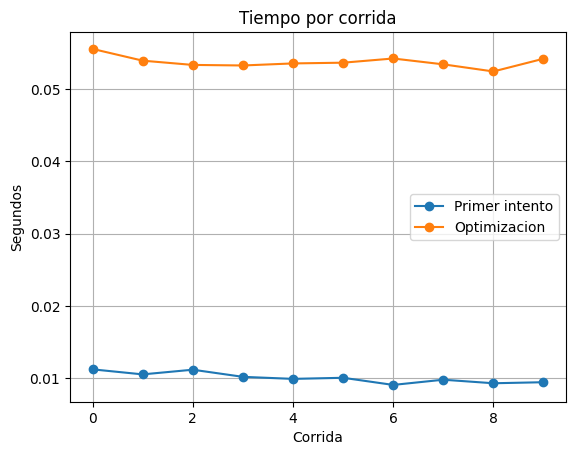

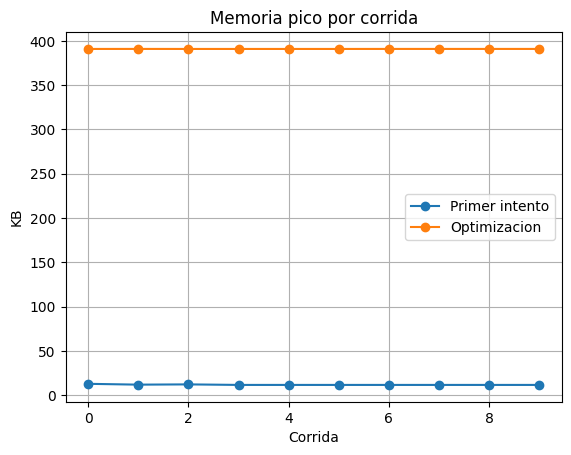

In [29]:
import time
import tracemalloc
import matplotlib.pyplot as plt


def medir(funcion, corridas=10):
    tiempos = []
    memorias = []
    resultados = []

    for _ in range(corridas):
        tracemalloc.start()

        tiempo_inicial = time.process_time()
        resultado = funcion()
        tiempo_final = time.process_time()

        _, memoria_pico = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        tiempos.append(tiempo_final - tiempo_inicial)
        memorias.append(memoria_pico / 1024)
        resultados.append(resultado)

    return {
        "resultado": resultados[0] if len(set(resultados)) == 1 else None,
        "consistente": len(set(resultados)) == 1,
        "tiempos": tiempos,
        "memorias": memorias,
    }


metodos = {
    "Primer intento": primer_intento,
    "Optimizacion": optimizacion,
}

comparaciones = {
    nombre: medir(funcion, corridas=10)
    for nombre, funcion in metodos.items()
}

for nombre, datos in comparaciones.items():
    print(f"\n--- {nombre} ---")
    print("Resultado:", datos["resultado"])
    print("Consistente:", datos["consistente"])
    print(f"Tiempo promedio: {sum(datos['tiempos']) / len(datos['tiempos']):.6f} s")
    print(f"Tiempo minimo: {min(datos['tiempos']):.6f} s")
    print(f"Memoria promedio: {sum(datos['memorias']) / len(datos['memorias']):.2f} KB")
    print(f"Memoria maxima: {max(datos['memorias']):.2f} KB")


plt.figure()
for nombre, datos in comparaciones.items():
    plt.plot(datos["tiempos"], marker="o", label=nombre)
plt.title("Tiempo por corrida")
plt.xlabel("Corrida")
plt.ylabel("Segundos")
plt.legend()
plt.grid()

plt.figure()
for nombre, datos in comparaciones.items():
    plt.plot(datos["memorias"], marker="o", label=nombre)
plt.title("Memoria pico por corrida")
plt.xlabel("Corrida")
plt.ylabel("KB")
plt.legend()
plt.grid()

plt.show()